29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 15us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 4s 1us/step
Training shape: (60000, 28, 28)
Testing shape: (10000, 28, 28)


C:\Users\Riddhi\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.8178 - loss: 0.5092 - val_accuracy: 0.8571 - val_loss: 0.4065
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8776 - loss: 0.3370 - val_accuracy: 0.8878 - val_loss: 0.3081
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8939 - loss: 0.2902 - val_accuracy: 0.8983 - val_loss: 0.2839
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9064 - loss: 0.2586 - val_accuracy: 0.8892 - val_loss: 0.3077
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9121 - loss: 0.2371 - val_accuracy: 0.9061 - val_loss: 0.2558
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9013 - loss: 0.2741
Test Accuracy: 0.9013000130653381
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


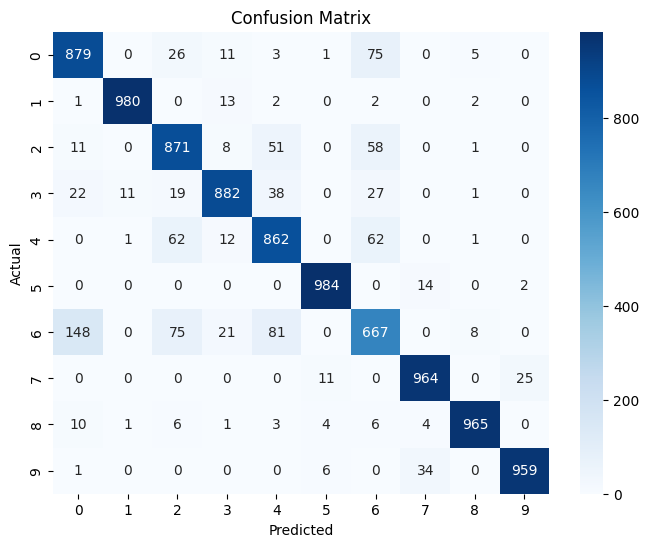

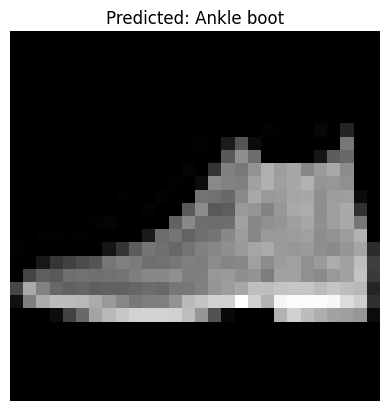

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import confusion_matrix


(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)


X_train = X_train / 255.0
X_test = X_test / 255.0


X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)


y_train_cat = to_categorical(y_train,10)
y_test_cat = to_categorical(y_test,10)


model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dense(10,activation='softmax'))


model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


history = model.fit(
    X_train,
    y_train_cat,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)


test_loss, test_accuracy = model.evaluate(X_test, y_test_cat)

print("Test Accuracy:", test_accuracy)


y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)


cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


class_names = ['T-shirt','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

plt.imshow(X_test[0].reshape(28,28), cmap='gray')
plt.title("Predicted: " + class_names[y_pred_classes[0]])
plt.axis('off')
plt.show()